<a href="https://colab.research.google.com/github/EmanSohail123/Loan-Approval/blob/main/ML_Phase5%2C6%2C7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Load dataset
df = pd.read_csv("/content/loan_data_new.csv")



# Separate Target (y) and Features (X)
y = df["Loan Status"]
X = df.drop(columns=["Loan Status"])

# If Target 'y' is text (e.g. 'Y'/'N'), convert to 1/0
if y.dtype == "object":
    y = y.map({"Y": 1, "N": 0, "Approved": 1, "Rejected": 0})

# 2. Automatically One-Hot Encode ALL text columns in X (fixes the 'OWN' string error)
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

# Fill any remaining NaN numerical values with median
X.fillna(X.median(), inplace=True)

# 3. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

# 4. Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("\n--- MODEL TRAINING COMPLETE ---")

# 5. Predictions & Probabilities
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)

# Display Preview
results_df = pd.DataFrame(
    {
        "Prob (Rejected - 0)": y_probs[:10, 0].round(4),
        "Prob (Approved - 1)": y_probs[:10, 1].round(4),
        "Predicted Class": y_pred[:10],
        "Actual Class": y_test.values[:10],
    }
)

print("\n--- PREDICTION & PROBABILITY RESULTS ---")
print(results_df)

Training Set Shape: (36000, 22)
Testing Set Shape: (9000, 22)

--- MODEL TRAINING COMPLETE ---

--- PREDICTION & PROBABILITY RESULTS ---
   Prob (Rejected - 0)  Prob (Approved - 1)  Predicted Class  Actual Class
0               0.9637               0.0363                0             0
1               0.9984               0.0016                0             0
2               0.9999               0.0001                0             0
3               0.9998               0.0002                0             0
4               0.8536               0.1464                0             1
5               0.3852               0.6148                1             1
6               0.9412               0.0588                0             0
7               0.9997               0.0003                0             0
8               0.9647               0.0353                0             0
9               0.5892               0.4108                0             0


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


             PHASE 6: EVALUATION METRICS           
Accuracy  : 0.8854 (88.54%)
Precision : 0.7506
Recall    : 0.7255
F1-Score  : 0.7379
ROC-AUC   : 0.9447

--- FULL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

Rejected (0)       0.92      0.93      0.93      7000
Approved (1)       0.75      0.73      0.74      2000

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.83      9000
weighted avg       0.88      0.89      0.88      9000



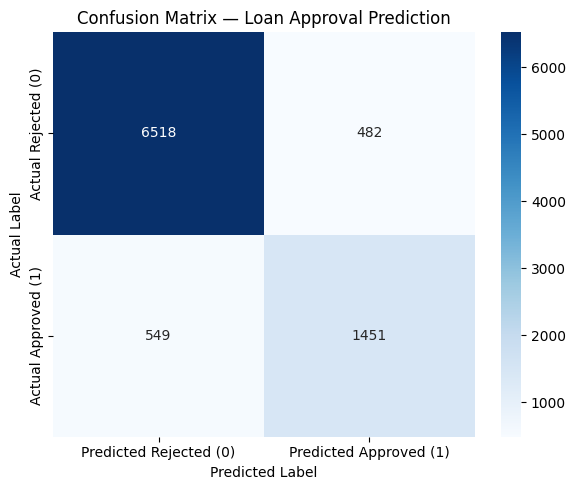

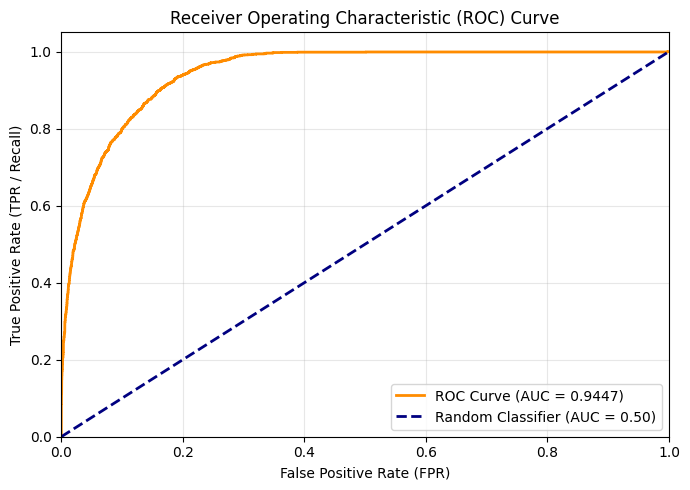

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# -------------------------------------------------------------
# STEP 1: Calculate Classification Metrics
# -------------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs[:, 1])

print("==================================================")
print("             PHASE 6: EVALUATION METRICS           ")
print("==================================================")
print(f"Accuracy  : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("==================================================\n")

# -------------------------------------------------------------
# STEP 2: Classification Report
# -------------------------------------------------------------
print("--- FULL CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=["Rejected (0)", "Approved (1)"]))

# -------------------------------------------------------------
# STEP 3: Visual 1 - Confusion Matrix Plot
# -------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Rejected (0)", "Predicted Approved (1)"],
    yticklabels=["Actual Rejected (0)", "Actual Approved (1)"],
)
plt.title("Confusion Matrix — Loan Approval Prediction")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# STEP 4: Visual 2 - ROC-AUC Curve Plot
# -------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_probs[:, 1])

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier (AUC = 0.50)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
import gradio as gr
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# 1. Load your dataset
df = pd.read_csv("/content/loan_data_new.csv")

# 2. Separate Target (y) and Features (X)
y = df["Loan Status"]
X = df.drop(columns=["Loan Status"])

# Target encoding if stored as string
if y.dtype == "object":
    y = y.map({"Y": 1, "N": 0, "Approved": 1, "Rejected": 0})

# 3. One-Hot Encode all categorical text columns automatically
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

# Handle any missing numeric values
X.fillna(X.median(), inplace=True)

# 4. Train the model on the dataset
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Save exact trained feature structure
feature_columns = X.columns.tolist()


# 5. Prediction Function for Gradio
def predict_loan(
    age,
    gender,
    education,
    person_income,
    employee_exp,
    home_ownership,
    loan_amount,
    loan_intent,
    loan_interest_rate,
    loan_percentage,
    credit_history,
    credit_score,
    previous_loan,
):
    # Construct input record with exact numerical values
    input_dict = {
        "Age": [float(age)],
        "Person Income": [float(person_income)],
        "Employee Experience": [float(employee_exp)],
        "Loan Amount": [float(loan_amount)],
        "Loan interest Rate": [float(loan_interest_rate)],
        "Loan percentage": [float(loan_percentage)],
        "Credit History": [float(credit_history)],
        "Credit Score": [float(credit_score)],
    }

    raw_df = pd.DataFrame(input_dict)

    # Encode categorical dropdown selections to match dummy variables
    # Handle 'Gender'
    if "Gender_Male" in feature_columns:
        raw_df["Gender_Male"] = 1 if gender == "Male" else 0

    # Handle 'Education'
    for col in [c for c in feature_columns if c.startswith("Education_")]:
        category_val = col.replace("Education_", "")
        raw_df[col] = 1 if education == category_val else 0

    # Handle 'Home Onwership'
    for col in [c for c in feature_columns if c.startswith("Home Onwership_")]:
        category_val = col.replace("Home Onwership_", "")
        raw_df[col] = 1 if home_ownership == category_val else 0

    # Handle 'Loan Intent'
    for col in [c for c in feature_columns if c.startswith("Loan Intent_")]:
        category_val = col.replace("Loan Intent_", "")
        raw_df[col] = 1 if loan_intent == category_val else 0

    # Handle 'Previous Loan'
    if "Previous Loan_Yes" in feature_columns:
        raw_df["Previous Loan_Yes"] = 1 if previous_loan == "Yes" else 0

    # Align columns to match training set
    input_encoded = raw_df.reindex(columns=feature_columns, fill_value=0)

    # Predict Probabilities
    probs = model.predict_proba(input_encoded)[0]
    prob_rejected = float(probs[0])
    prob_approved = float(probs[1])

    # Final Classification
    if prob_approved >= 0.50:
        status = "✅ LOAN APPROVED"
    else:
        status = "❌ LOAN REJECTED"

    return status, f"{prob_approved * 100:.2f}%", f"{prob_rejected * 100:.2f}%"


# 6. Build Gradio UI matching dataset inputs
app = gr.Interface(
    fn=predict_loan,
    inputs=[
        gr.Number(label="Age", value=28),
        gr.Dropdown(["Male", "Female"], label="Gender", value="Male"),
        gr.Dropdown(
            ["Bachelor", "Master", "High School", "Associate", "Doctorate"],
            label="Education",
            value="Bachelor",
        ),
        gr.Number(label="Person Income ($)", value=55000),
        gr.Number(label="Employee Experience (Years)", value=3),
        gr.Dropdown(
            ["RENT", "OWN", "MORTGAGE", "OTHER"],
            label="Home Ownership",
            value="RENT",
        ),
        gr.Number(label="Loan Amount ($)", value=10000),
        gr.Dropdown(
            [
                "PERSONAL",
                "EDUCATION",
                "MEDICAL",
                "VENTURE",
                "HOMEIMPROVEMENT",
                "DEBTCONSOLIDATION",
            ],
            label="Loan Intent",
            value="PERSONAL",
        ),
        gr.Number(label="Loan Interest Rate (%)", value=11.2),
        gr.Number(label="Loan Percentage (Income Ratio)", value=0.18),
        gr.Number(label="Credit History (Years)", value=4),
        gr.Number(label="Credit Score", value=680),
        gr.Dropdown(["Yes", "No"], label="Previous Loan", value="No"),
    ],
    outputs=[
        gr.Textbox(label="Final Decision Classification"),
        gr.Textbox(label="Approval Probability"),
        gr.Textbox(label="Rejection Probability"),
    ],
    title="🏦 Loan Approval Prediction Application",
    description="Interactive ML application to predict loan approval status based on applicant financial metrics.",
)

# Launch application interface
app.launch(share=True)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://648a0e0d8ea13094ed.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
